<a href="https://colab.research.google.com/github/Rabidhau/assessment0/blob/main/TextClassificationPortfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The csv dataset contains the collection of comments that has to be classified as:

0 - hate speech

1 - offensive language

2 - neither



# Load and understand the data.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd

df = pd.read_csv(
    '/content/hatevsoffensive_language.csv')

In [ ]:
np.shape(df)

(24783, 2)

In [ ]:
df.head()

,label,text
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
from sklearn.preprocessing import LabelEncoder

#convert classes to integer labels
le = LabelEncoder()
labels_encoded = le.fit_transform(df['label'])

# Clean the text:

In [ ]:
!pip install contractions
!pip install nltk

In [ ]:
import nltk
# necessary NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import re
import string
import contractions
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tokenize.treebank import TreebankWordDetokenizer

# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase all text
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions (@user) and hashtags (#hashtag)
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters and punctuation (except spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Handle contractions
    text = contractions.fix(text)

    # Tokenize the text
    words = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]

    # Lemmatize words to reduce them to their base form
    words = [lemmatizer.lemmatize(word) for word in words]

    # Rejoin words into a cleaned sentence
    return ' '.join(words)


In [ ]:
df['cleaned_text'] = df['text'].apply(clean_text)
# Check the column names
print(df['cleaned_text'])

0        rt woman complain cleaning house amp man alway...
1        rt boy dat coldtyga dwn bad cuffin dat hoe st ...
2        rt dawg rt ever fuck bitch start cry confused ...
3                                      rt look like tranny
4        rt shit hear might true might faker bitch told ya
                               ...                        
24778    yous muthafin lie right tl trash mine bible sc...
24779      gone broke wrong heart baby drove redneck crazy
24780       young buck want eat dat nigguh like fuckin dis
24781                       youu got wild bitch tellin lie
24782    ruffled ntac eileen dahlia beautiful color com...
Name: cleaned_text, Length: 24783, dtype: object


Visualize the cleaned data:

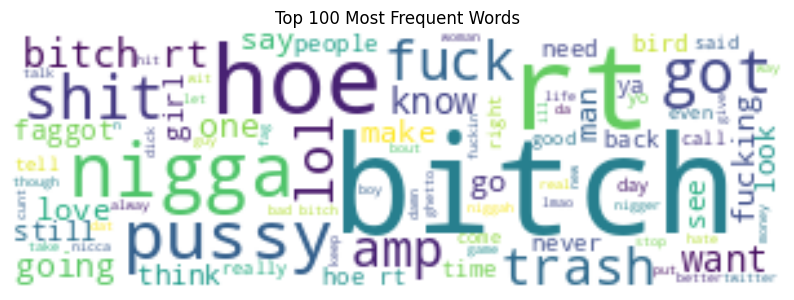

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# --- Visualization: Word Cloud (Top 100 Words) ---
all_words = ' '.join(df['cleaned_text'])
# Generate WordCloud with only top 100 words
wordcloud = WordCloud(
width=300,
height=100,
background_color='white',
max_words=100 # Limit to top 100 words
).generate(all_words)
# Plot settings
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
# Split
X_train, X_temp, y_train, y_temp = train_test_split(
df['cleaned_text'], # Features (text)
labels_encoded ,# Labels
test_size=0.2,
random_state=42
)

In [ ]:
# split the set into validation (50%) and test (50% )
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,  # Temporary features
    y_temp,  # Temporary labels
    test_size=0.5,  # Split equally into validation and test sets (50% each)
    random_state=42
)

Handling imbalance

In [ ]:
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler

# Convert to 2D arrays (required by RandomUnderSampler)
X_train_2d = X_train.values.reshape(-1, 1)  # Reshape to (n_samples, 1)
y_train_2d = y_train

# Check class distribution before undersampling
print("Original class distribution of training:", Counter(y_train))  # Output: Counter

# Apply Random Undersampling with specific sampling_strategy
undersampler = RandomUnderSampler(
    sampling_strategy={1: 1500, 2: 1500},  # Set both classes to 1500
    random_state=42
)
X_train_res, y_train_res = undersampler.fit_resample(X_train_2d, y_train_2d)

# Convert back to original format
X_train_res = pd.Series(X_train_res.flatten())  # Flatten to 1D

print("Resampled class distribution:", Counter(y_train_res))

Original class distribution of training: Counter({2: 15358, 1: 3328, 0: 1140})
Resampled class distribution: Counter({1: 1500, 2: 1500, 0: 1140})


Tokenization and Padding:


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_res)
print(f"Total unique words: {len(tokenizer.word_index)}")

Total unique words: 7035


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_res) # Vocabulary based ONLY on training data

# Use the same tokenizer to transform all sets
X_train_seq = tokenizer.texts_to_sequences(X_train_res)
X_val_seq= tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

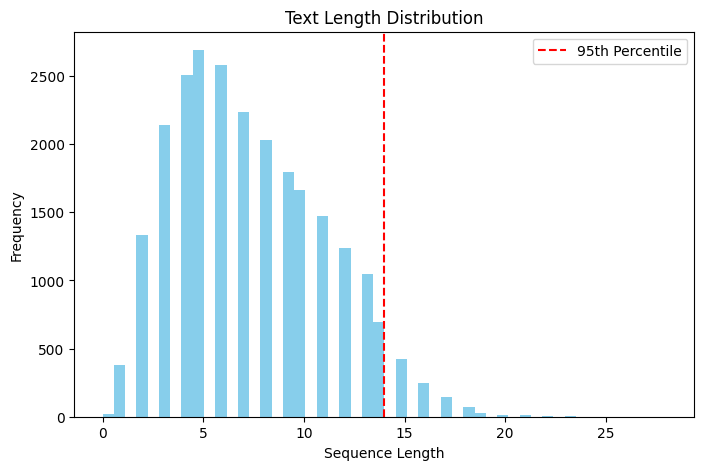

In [ ]:
X_seq = tokenizer.texts_to_sequences(df['cleaned_text'])
seq_lengths = [len(seq) for seq in X_seq]
plt.figure(figsize=(8, 5))
plt.hist(seq_lengths, bins=50, color='skyblue')
plt.title('Text Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')

plt.axvline(np.percentile(seq_lengths, 95), color='red', linestyle='dashed', label='95th Percentile')
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Calculate max_len using percentile
seq_lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(seq_lengths, 95))
# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [ ]:
import numpy as np
from collections import Counter

class_counts = Counter(y_train_res)
print("Class distribution:", class_counts)

Class distribution: Counter({1: 1500, 2: 1500, 0: 1140})


In [ ]:
!pip install numpy==1.24.3 scipy==1.10.1

# Trying Imabalanced classes handling:

In [ ]:
!pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state = 2)
X_train_res, y_train_res = sm.fit_resample(X_train_pad, y_train.ravel())

print('After OverSampling, the shape of train_X: {}'.format(X_train_res.shape))
print('After OverSampling, the shape of train_y: {} \n'.format(y_train_res.shape))

print("After OverSampling, counts of label '2': {}".format(sum(y_train_res == 2)))
print("After OverSampling, counts of label '1': {}".format(sum(y_train_res == 1)))
print("After OverSampling, counts of label '0': {}".format(sum(y_train_res == 0)))


After OverSampling, the shape of train_X: (46074, 14)
After OverSampling, the shape of train_y: (46074,) 

After OverSampling, counts of label '2': 15358
After OverSampling, counts of label '1': 15358
After OverSampling, counts of label '0': 15358


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight(class_weight='balanced',
                                classes=np.unique(labels_encoded),
                                y=labels_encoded)
class_weights_dict = dict(enumerate(weights))

# Model Building and Training:

# Simple RNN with a trainable Embedding layer.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import time

# Parameters
vocab_size = 5000
embedding_dim = 128
rnn_units = 64
#maxlen = X_train_pad.shape[1]  # same maxlen used for padding

# Build model step-by-step
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model.add(SimpleRNN(units=rnn_units))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))  # 3-class classification

# Assign model to variable rnn
rnn = model

# Compile
rnn.compile(optimizer=Adam(learning_rate=1e-4),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callback = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True,verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6,verbose=1)
]

start_time = time.time()
# Train
history= rnn.fit(X_train_pad, y_train_res, epochs=10, batch_size=32, validation_data=(X_val_pad, y_val),callbacks=callback)
rnn_time = time.time() - start_time
print(f"Simple Rnn model training time: {rnn_time:.2f} seconds")

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.3273 - loss: 1.1120 - val_accuracy: 0.5492 - val_loss: 1.0163 - learning_rate: 1.0000e-04
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.4213 - loss: 1.0625 - val_accuracy: 0.6844 - val_loss: 0.9012 - learning_rate: 1.0000e-04
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6124 - loss: 0.9147 - val_accuracy: 0.7062 - val_loss: 0.7239 - learning_rate: 1.0000e-04
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7539 - loss: 0.6351 - val_accuracy: 0.7728 - val_loss: 0.5549 - learning_rate: 1.0000e-04
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.8615 - loss: 0.3908 - val_accuracy: 0.7712 - val_loss: 0.5934 - learning_rate: 1.0000e-04
Epoch 6/10
128/130 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9128 - loss: 0.2792
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy

Visualization:

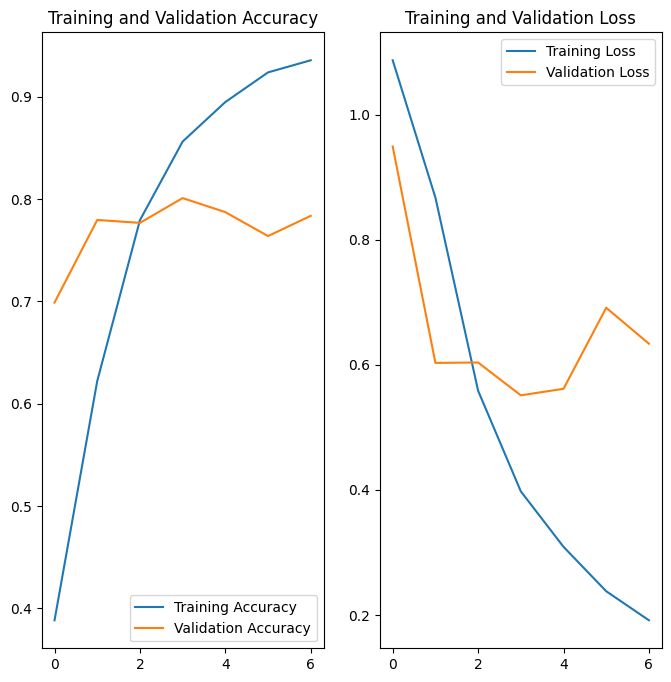

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range=range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Evaluation:

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions on the test set
y_pred = rnn.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class labels

# Accuracy score
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Classification Report
cr = classification_report(y_test, y_pred_classes, target_names=le.classes_)
print("Classification Report:")
print(cr)

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Accuracy: 0.8116
Confusion Matrix:
[[  53   21   59]
 [  11  325   86]
 [ 145  145 1634]]
Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.25      0.40      0.31       133
           neither       0.66      0.77      0.71       422
offensive language       0.92      0.85      0.88      1924

          accuracy                           0.81      2479
         macro avg       0.61      0.67      0.63      2479
      weighted avg       0.84      0.81      0.82      2479



In [ ]:
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,957,643 (7.47 MB)

 Trainable params: 652,547 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,305,096 (4.98 MB)

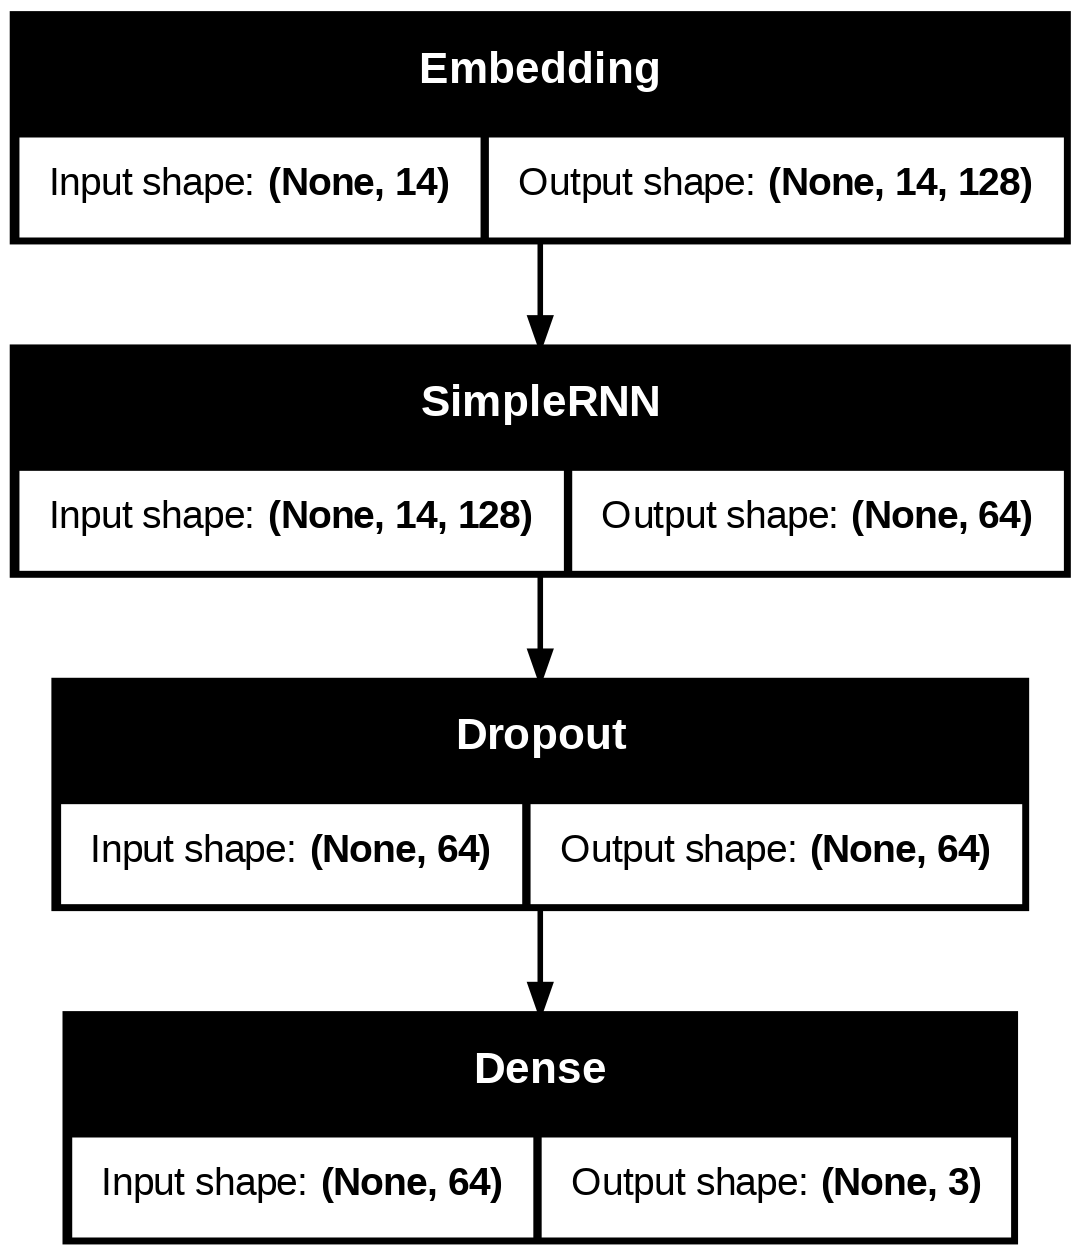

In [ ]:
from tensorflow import keras
keras.utils.plot_model(rnn, show_shapes=True)

# LSTM with a trainable Embedding layer.

In [ ]:
from tensorflow.keras.layers import LSTM,SpatialDropout1D
from tensorflow.keras.optimizers import Adam

#parameters
vocab_size = 5000  # Size of vocabulary
lstm_units = 32
embedding_dim = 64

# Build the model
model = Sequential([
    Embedding(vocab_size, embedding_dim),
    SpatialDropout1D(0.5) ,# Add dropout to embedding layer
    LSTM(lstm_units,
         kernel_regularizer=tf.keras.regularizers.l2(0.01)),  # L2 regularization
    Dropout(0.5),
    Dense(3, activation='softmax')
])

lstm=model

optimizer = Adam(learning_rate=1e-4)
lstm.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)  # Slower LR reduction
]

start_time = time.time()
# Train
history= lstm.fit(X_train_pad, y_train_res, epochs=20, batch_size=32, validation_data=(X_val_pad, y_val),callbacks=callback)
lstm_time = time.time() - start_time
print(f"LSTM model with a trainable Embedding layer training time: {lstm_time:.2f} seconds")

Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3424 - loss: 1.9050 - val_accuracy: 0.7462 - val_loss: 1.7462 - learning_rate: 1.0000e-04
Epoch 2/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4042 - loss: 1.7413 - val_accuracy: 0.7333 - val_loss: 1.6014 - learning_rate: 1.0000e-04
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3899 - loss: 1.6132 - val_accuracy: 0.7526 - val_loss: 1.4727 - learning_rate: 1.0000e-04
Epoch 4/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4119 - loss: 1.5010 - val_accuracy: 0.7571 - val_loss: 1.3663 - learning_rate: 1.0000e-04
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4494 - loss: 1.4059 - val_accuracy: 0.7793 - val_loss: 1.2421 - learning_rate: 1.0000e-04
Epoch 6/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4957 - loss: 1.2892 - val_accuracy: 0.8216 - val_loss: 1.0056 - learning_rate: 1.0000e-04
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc

Visualization:

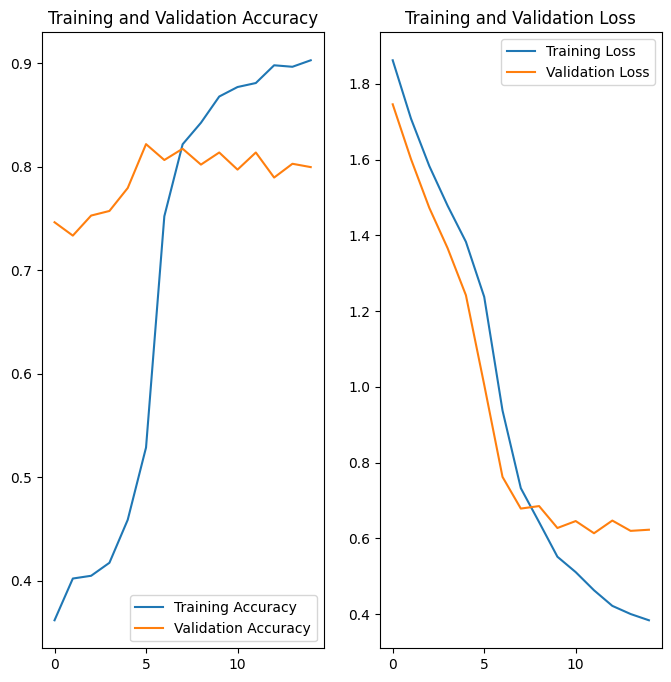

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range=range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Evaluation:

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions on the test set
y_pred = lstm.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class labels

# Accuracy score
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Classification Report
cr = classification_report(y_test, y_pred_classes, target_names=le.classes_)
print("Classification Report:")
print(cr)

78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Accuracy: 0.8201
Confusion Matrix:
[[  57   29   47]
 [  10  373   39]
 [ 167  154 1603]]
Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.24      0.43      0.31       133
           neither       0.67      0.88      0.76       422
offensive language       0.95      0.83      0.89      1924

          accuracy                           0.82      2479
         macro avg       0.62      0.72      0.65      2479
      weighted avg       0.86      0.82      0.84      2479



In [ ]:
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 14, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 14, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 997,547 (3.81 MB)

 Trainable params: 332,515 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 665,032 (2.54 MB)

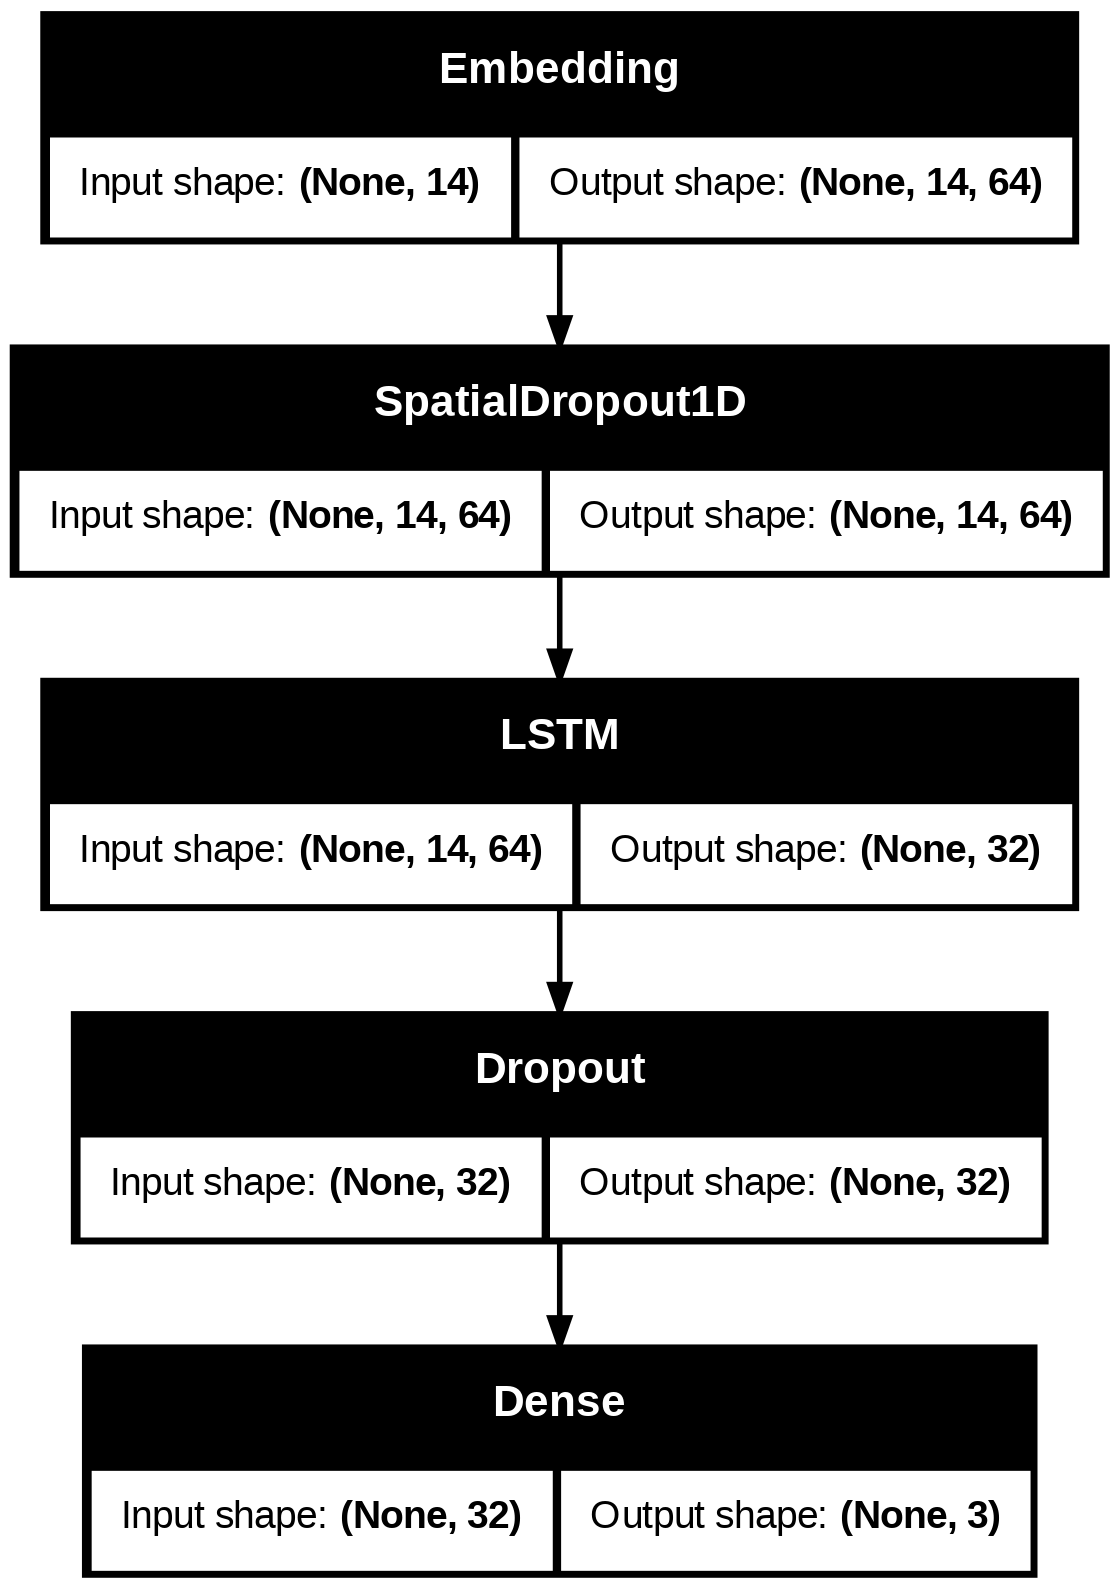

In [ ]:
from tensorflow import keras
keras.utils.plot_model(lstm, show_shapes=True)

# Pre-trained word2vec embedding vector with LSTM

In [ ]:
!pip install gensim
!pip install jax==0.4.13

In [ ]:
# Remove the corrupted package
!pip uninstall cipy -y

# Remove all conflicting packages
!pip uninstall numpy scipy jax jaxlib -y

# Clear pip cache
!pip cache purge

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
Found existing installation: jax 0.4.13
Uninstalling jax-0.4.13:
  Successfully uninstalled jax-0.4.13
Found existing installation: jaxlib 0.5.1
Uninstalling jaxlib-0.5.1:
  Successfully uninstalled jaxlib-0.5.1
Files removed: 59


In [ ]:
import gensim.downloader as api
# Load Pre-trained GloVe Embeddings
embedding_model = api.load('glove-twitter-100')

[==================================================] 100.0% 387.1/387.1MB downloaded


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

embedding_dim = 100 # Match with downloaded GloVe model dimension
vocab_size = len(tokenizer.word_index) + 1 # Add 1 for  for padding (index 0)

# Initialize the embedding matrix with zeros (vocab_size, embedding_dim)
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Map each word in the tokenizer’s word index to its Word2Vec vector
for word, index in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
else:
# Words not found in embedding index will be all-zeros
  pass


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential()
# Use the pre-trained Word2Vec embeddings in the Embedding Layer
model.add(Embedding(input_dim=vocab_size,
  output_dim=embedding_dim,
  weights=[embedding_matrix], # Load the pre-trained Word2Vec embeddings
  trainable=False
))
model.add(LSTM(64)) # Add an LSTM layer
model.add(Dense(3, activation='softmax')) # Output layer for hate speech classification

lstm2=model

# Compile
lstm2.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
# Train
history= lstm2.fit(X_train_pad, y_train_res, epochs=5, batch_size=32, validation_data=(X_val_pad, y_val))
lstm2_time = time.time() - start_time
print(f"LSTM model with a pre-trained Embedding layer training time: {lstm2_time:.2f} seconds")


Epoch 1/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5738 - loss: 0.9160 - val_accuracy: 0.8249 - val_loss: 0.4711
Epoch 2/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8035 - loss: 0.5074 - val_accuracy: 0.8301 - val_loss: 0.4579
Epoch 3/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8181 - loss: 0.4704 - val_accuracy: 0.8426 - val_loss: 0.4086
Epoch 4/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8368 - loss: 0.4308 - val_accuracy: 0.8370 - val_loss: 0.4475
Epoch 5/5
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8508 - loss: 0.3970 - val_accuracy: 0.8313 - val_loss: 0.4414
LSTM model with a pre-trained Embedding layer training time: 15.15 seconds


In [ ]:
# Save the trained model
lstm2.save("hatespeech_model.keras")

# Save the tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save the LabelEncoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


Visualization:

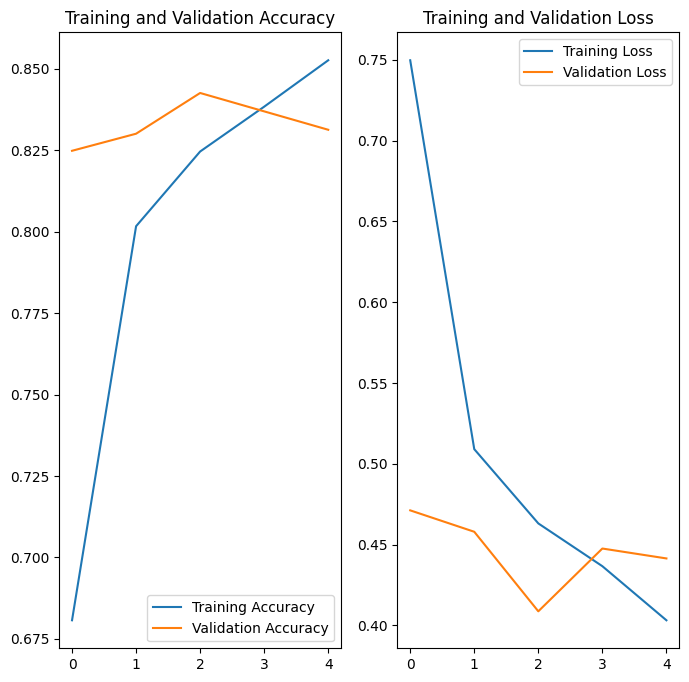

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range=range(len(acc))

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Evaluation:

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predictions on the test set
y_pred = lstm2.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1) # Convert probabilities to class labels

# Accuracy score
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Classification Report
cr = classification_report(y_test, y_pred_classes, target_names=le.classes_)
print("Classification Report:")
print(cr)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.8237
Confusion Matrix:
[[  88   16   29]
 [  29  372   21]
 [ 241  101 1582]]
Classification Report:
                    precision    recall  f1-score   support

        hate speec       0.25      0.66      0.36       133
           neither       0.76      0.88      0.82       422
offensive language       0.97      0.82      0.89      1924

          accuracy                           0.82      2479
         macro avg       0.66      0.79      0.69      2479
      weighted avg       0.90      0.82      0.85      2479



In [ ]:
lstm2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 14, 100)        │       703,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 831,007 (3.17 MB)

 Trainable params: 42,435 (165.76 KB)

 Non-trainable params: 703,700 (2.68 MB)

 Optimizer params: 84,872 (331.54 KB)

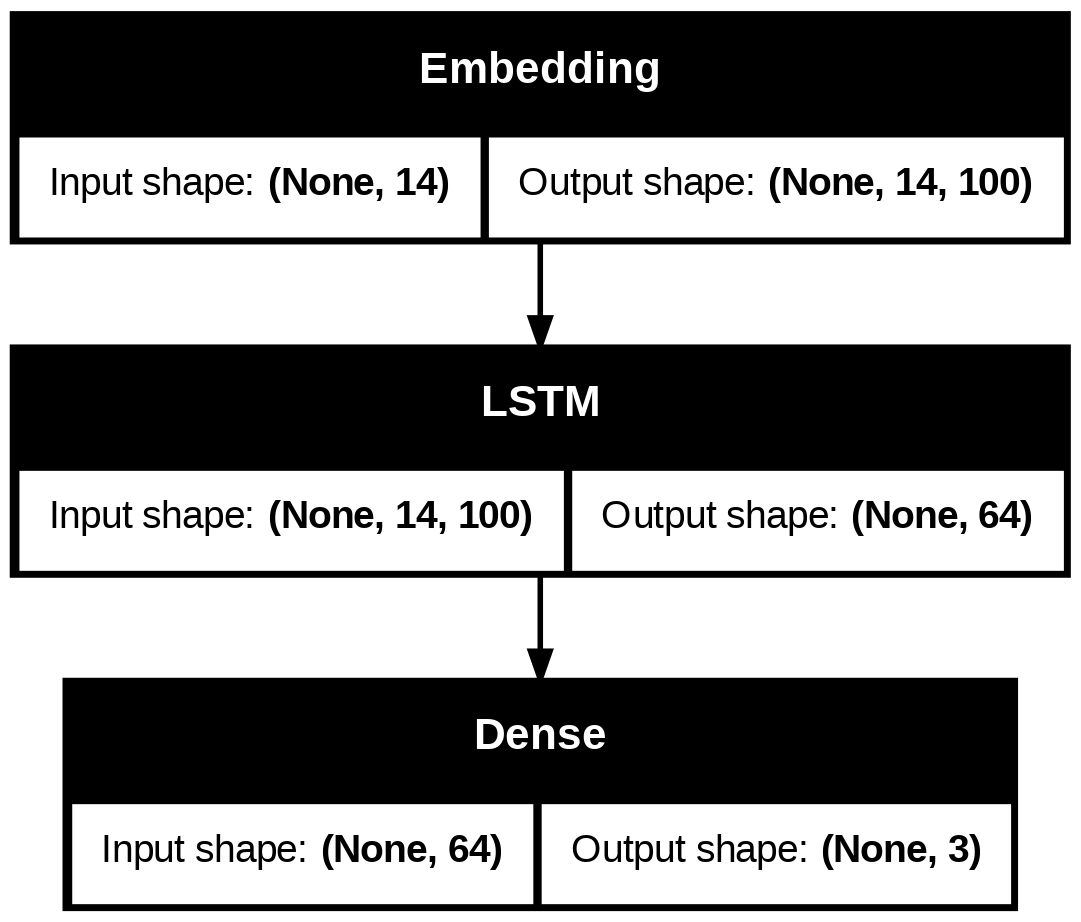

In [ ]:
from tensorflow import keras
keras.utils.plot_model(lstm2, show_shapes=True)

#  Performance Comparison of the Model 1 vs. Model 2 vs. Model 3.

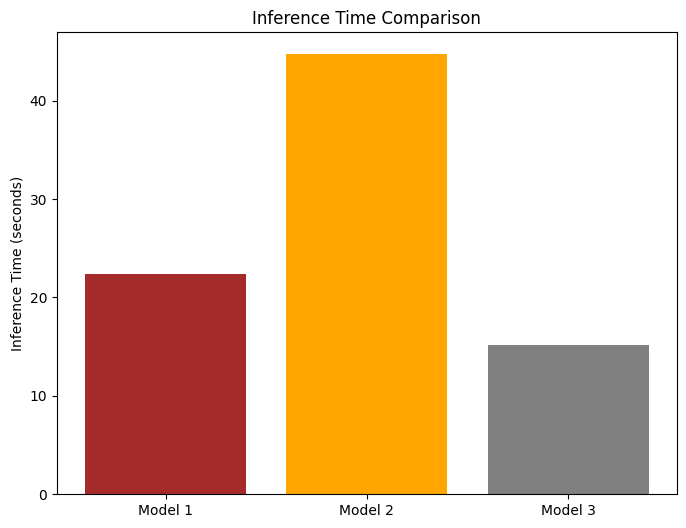

In [ ]:
# Plot Inference Time Bar Graph
models = ['Model 1', 'Model 2', 'Model 3']
inference_times = [rnn_time, lstm_time, lstm2_time]

plt.figure(figsize=(8, 6))
plt.bar(models, inference_times, color=['brown', 'orange', 'gray'])
plt.ylabel('Inference Time (seconds)')
plt.title('Inference Time Comparison')
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize

# Classes from label encoder
classes = le.classes_
n_classes = len(classes)

# Ensure y_test is an array of integer labels
y_test_bin = label_binarize(y_test, classes=range(n_classes))  # shape: (n_samples, n_classes)

In [ ]:
from sklearn.metrics import roc_curve, auc
import numpy as np

def compute_roc_auc(y_true_bin, y_probs, n_classes):
    fpr, tpr, roc_auc = {}, {}, {}

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
    roc_auc["macro"] = auc(all_fpr, mean_tpr)

    return fpr, tpr, roc_auc


In [ ]:
# prediction probabilities
y_prob1 = rnn.predict(X_test_pad)
y_prob2 = lstm.predict(X_test_pad)
y_prob3 = lstm2.predict(X_test_pad)

# call function
fpr1, tpr1, auc1 = compute_roc_auc(y_test_bin, y_prob1, n_classes)
fpr2, tpr2, auc2 = compute_roc_auc(y_test_bin, y_prob2, n_classes)
fpr3, tpr3, auc3 = compute_roc_auc(y_test_bin, y_prob3, n_classes)


78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


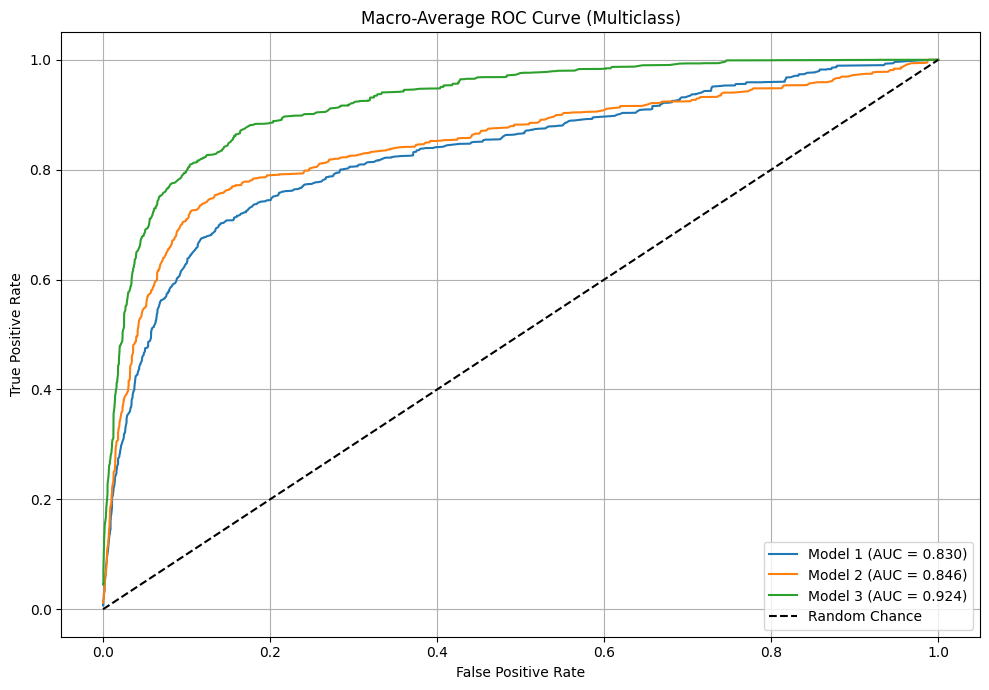

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.plot(fpr1["macro"], tpr1["macro"], label=f'Model 1 (AUC = {auc1["macro"]:.3f})')
plt.plot(fpr2["macro"], tpr2["macro"], label=f'Model 2 (AUC = {auc2["macro"]:.3f})')
plt.plot(fpr3["macro"], tpr3["macro"], label=f'Model 3 (AUC = {auc3["macro"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve (Multiclass)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# GUI for Real Time Prediction:

In [ ]:
!pip install gradio

In [ ]:
!pip install --upgrade --quiet tensorflow gradio
!pip uninstall -y jax jaxlib  # Remove conflicting packages

In [ ]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

# Load model components
def load_components():
    with open('tokenizer.pkl', 'rb') as f:
        tokenizer = pickle.load(f)
    model = load_model('hatespeech_model.keras')
    return tokenizer, model

tokenizer, model = load_components()
class_names = ['Neither', 'Offensive', 'Hate']

# Prediction function
def predict_hate_speech(text):
    # Preprocess input
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=100)

    # Make prediction
    probs = model.predict(padded)[0]
    return {class_names[i]: float(probs[i]) for i in range(3)}

# Gradio interface
demo = gr.Interface(
    fn=predict_hate_speech,
    inputs=gr.Textbox(label="Enter text", lines=3, placeholder="Type your text here..."),
    outputs=gr.Label(label="Prediction", num_top_classes=3),
    title="🚨 Hate Speech Detector",
    description="This AI model classifies texts into: Neither, Offensive, or Hate speech.",
    examples=[
        ["I love this community!"],
        ["That's a stupid idea, but you do you..."],
        ["People like you should be eliminated from society"]
    ],
    theme="soft"
)

# Launch the app
if __name__ == "__main__":
    demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://13711305e09c0155ae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
